# Original Analysis
Loading and exploring the LINK dataset NWB files.

## Setup

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pynwb import NWBHDF5IO

# Point to the downloaded dataset
DATA_DIR = os.path.join('.', 'data', '001201', 'sub-Monkey-N')

# Sorted list of all session NWB files
nwb_files = sorted([f for f in os.listdir(DATA_DIR) if f.endswith('.nwb')])
print(f'Found {len(nwb_files)} sessions')
print('First 5:', nwb_files[:5])

Found 312 sessions
First 5: ['sub-Monkey-N_ses-20200127_ecephys.nwb', 'sub-Monkey-N_ses-20200130_ecephys.nwb', 'sub-Monkey-N_ses-20200204_ecephys.nwb', 'sub-Monkey-N_ses-20200205_ecephys.nwb', 'sub-Monkey-N_ses-20200206_ecephys.nwb']


## Load a Single Session

Each NWB file contains:
- **Neural**: `SpikingBandPower` and `ThresholdCrossings` — shape `(T, 96)` at 4ms bins, 96 Utah array channels
- **Behavior**: `index_position`, `mrs_position`, `index_velocity`, `mrs_velocity` — shape `(T, 1)`
- **Trials**: per-trial metadata with start/stop times and finger targets

In [2]:
SESSION_IDX = 0  # change to load a different session
nwb_path = os.path.join(DATA_DIR, nwb_files[SESSION_IDX])
print('Loading:', nwb_files[SESSION_IDX])

with NWBHDF5IO(nwb_path, 'r') as io:
    nwb = io.read()

    # Neural data — divide SBP by 0.25 to normalize
    sbp = (nwb.analysis['SpikingBandPower'].data[:] / 0.25).astype(np.float64)        # (T, 96)
    tc  = nwb.analysis['ThresholdCrossings'].data[:].astype(np.float64)               # (T, 96)

    # Behavioral data
    index_pos = nwb.analysis['index_position'].data[:].ravel()   # (T,)
    mrs_pos   = nwb.analysis['mrs_position'].data[:].ravel()     # (T,)
    index_vel = nwb.analysis['index_velocity'].data[:].ravel()   # (T,)
    mrs_vel   = nwb.analysis['mrs_velocity'].data[:].ravel()     # (T,)

    # Trials
    trials_df = nwb.trials.to_dataframe()

    # Electrode metadata
    electrodes_df = nwb.electrodes.to_dataframe()

    session_info = {
        'description': nwb.session_description,
        'start_time':  nwb.session_start_time,
        'subject':     nwb.subject.description,
    }

print('Session:', session_info)
print(f'Neural data shape: {sbp.shape}  (time bins x channels)')
print(f'Num trials: {len(trials_df)}')

Loading: sub-Monkey-N_ses-20200127_ecephys.nwb
Session: {'description': 'Neural and behavioral data for target style CO', 'start_time': datetime.datetime(2020, 1, 27, 0, 0, tzinfo=tzutc()), 'subject': 'Monkey N'}
Neural data shape: (27649, 96)  (time bins x channels)
Num trials: 375


## Inspect Trials

In [3]:
trials_df[['start_time', 'stop_time', 'index_target_position', 'mrs_target_position', 'target_style']].head(10)

,start_time,stop_time,index_target_position,mrs_target_position,target_style
id,,,,,
0,8.41,9.67,0.3,0.3,CO
1,9.69,11.05,0.5,0.5,CO
2,11.07,12.95,0.7,0.5,CO
3,12.97,13.77,0.5,0.5,CO
4,13.79,17.01,0.2,0.8,CO
5,17.03,18.47,0.5,0.5,CO
6,18.49,20.09,0.3,0.5,CO
7,20.11,21.99,0.5,0.5,CO
8,22.01,25.71,0.8,0.2,CO


## Inspect Electrode Metadata

In [4]:
print('Array names:', electrodes_df['array_name'].unique())
print('Locations:', electrodes_df['location'].unique())
electrodes_df[['array_name', 'row', 'col', 'imp']].head(10)

Array names: ['Lateral' 'Medial']
Locations: ['Hand area of M1']


,array_name,row,col,imp
id,,,,
0,Lateral,1,0,267000.0
1,Lateral,0,0,72000.0
2,Lateral,2,0,139000.0
3,Lateral,3,0,232000.0
4,Lateral,5,0,229000.0
5,Lateral,6,0,236000.0
6,Lateral,4,0,337000.0
7,Lateral,2,1,12537000.0
8,Lateral,7,0,104000.0


## Quick Visualization: Neural + Behavioral Traces

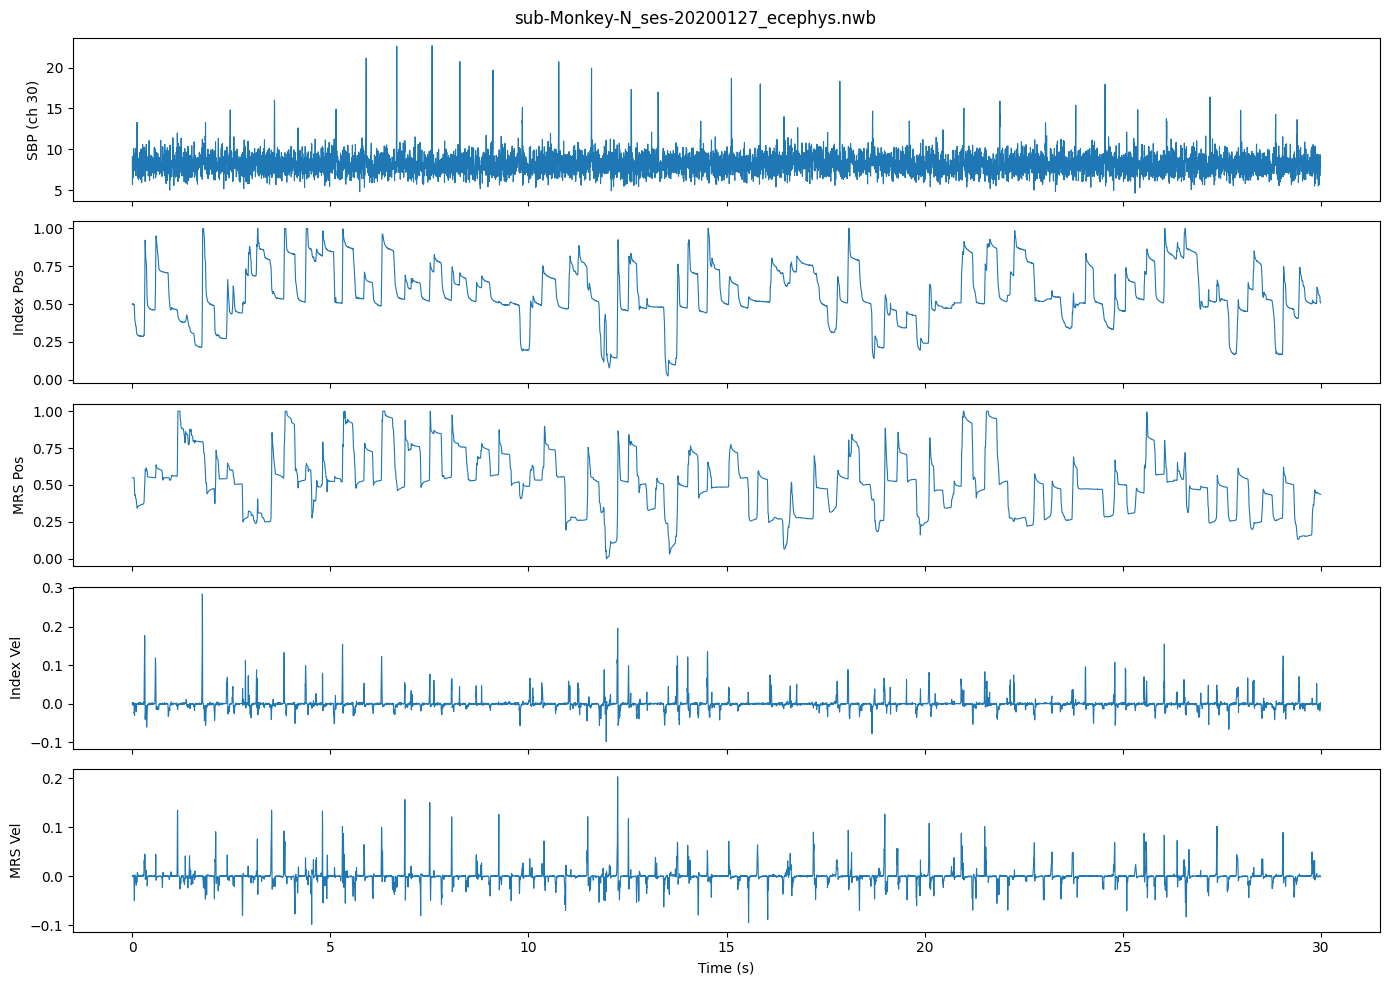

In [5]:
BIN_SIZE = 0.004  # 4ms per bin
time = np.arange(sbp.shape[0]) * BIN_SIZE

# Plot first 30 seconds
mask = time < 30

fig, axs = plt.subplots(5, 1, figsize=(14, 10), sharex=True)

axs[0].plot(time[mask], sbp[mask, 30], lw=0.8)
axs[0].set_ylabel('SBP (ch 30)')

for i, (label, trace) in enumerate([
    ('Index Pos', index_pos),
    ('MRS Pos',   mrs_pos),
    ('Index Vel', index_vel),
    ('MRS Vel',   mrs_vel),
]):
    axs[i+1].plot(time[mask], trace[mask], lw=0.8)
    axs[i+1].set_ylabel(label)

axs[-1].set_xlabel('Time (s)')
plt.suptitle(nwb_files[SESSION_IDX])
plt.tight_layout()
plt.show()

## Slice Data by Trial

Convert trial start/stop times to bin indices and extract per-trial arrays.

In [6]:
def time_to_bin(t, bin_size=0.004):
    return int(round(t / bin_size))

trial_sbp = []
trial_behavior = []

for _, trial in trials_df.iterrows():
    start_bin = time_to_bin(trial['start_time'])
    stop_bin  = time_to_bin(trial['stop_time'])
    trial_sbp.append(sbp[start_bin:stop_bin])
    trial_behavior.append(np.column_stack([
        index_pos[start_bin:stop_bin],
        mrs_pos[start_bin:stop_bin],
        index_vel[start_bin:stop_bin],
        mrs_vel[start_bin:stop_bin],
    ]))

print(f'Extracted {len(trial_sbp)} trials')
print(f'Example trial neural shape: {trial_sbp[0].shape}  (bins x channels)')
print(f'Example trial behavior shape: {trial_behavior[0].shape}  (bins x [idx_pos, mrs_pos, idx_vel, mrs_vel])')

Extracted 375 trials
Example trial neural shape: (316, 96)  (bins x channels)
Example trial behavior shape: (316, 4)  (bins x [idx_pos, mrs_pos, idx_vel, mrs_vel])


## Load All Sessions

Iterate over all 312 sessions and collect summary stats. Modify to extract whatever you need.

In [7]:
session_records = []

for fname in nwb_files:
    path = os.path.join(DATA_DIR, fname)
    with NWBHDF5IO(path, 'r') as io:
        nwb = io.read()
        T = nwb.analysis['SpikingBandPower'].data.shape[0]
        n_trials = len(nwb.trials)
        session_records.append({
            'file':     fname,
            'date':     nwb.session_start_time.date(),
            'n_bins':   T,
            'duration_s': T * 0.004,
            'n_trials': n_trials,
        })

sessions = pd.DataFrame(session_records)
print(sessions.describe())
sessions.head()

             n_bins  duration_s  n_trials
count    312.000000  312.000000     312.0
mean   24717.358974   98.869436     375.0
std     2340.434488    9.361738       0.0
min    20828.000000   83.312000     375.0
25%    22826.750000   91.307000     375.0
50%    24655.500000   98.622000     375.0
75%    25958.750000  103.835000     375.0
max    35253.000000  141.012000     375.0


,file,date,n_bins,duration_s,n_trials
0,sub-Monkey-N_ses-20200127_ecephys.nwb,2020-01-27,27649,110.596,375
1,sub-Monkey-N_ses-20200130_ecephys.nwb,2020-01-30,26944,107.776,375
2,sub-Monkey-N_ses-20200204_ecephys.nwb,2020-02-04,26441,105.764,375
3,sub-Monkey-N_ses-20200205_ecephys.nwb,2020-02-05,26571,106.284,375
4,sub-Monkey-N_ses-20200206_ecephys.nwb,2020-02-06,26957,107.828,375


---
## Behavioral PCA: Representing Each Day as a 2D Point

For each session we load the 4 behavioral signals `(T, 4)`, run PCA to get `(T, 2)`, then take the **mean across time** to get a single `(2,)` point representing that day. Collecting all 312 days gives a `(312, 2)` matrix which we cluster with k-means (k=4).

In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

KINEMATIC_KEYS = ['index_position', 'mrs_position', 'index_velocity', 'mrs_velocity']

# --- Pass 1: load all behavioral data and fit a global scaler + PCA ---
print('Pass 1: loading behavioral data for global scaler/PCA fit...')
all_behavior = []
day_files = []
day_dates = []

for fname in nwb_files:
    path = os.path.join(DATA_DIR, fname)
    with NWBHDF5IO(path, 'r') as io:
        nwb = io.read()
        behavior = np.column_stack([
            nwb.analysis[k].data[:].ravel() for k in KINEMATIC_KEYS
        ])  # (T, 4)
        date = nwb.session_start_time.date()
    all_behavior.append(behavior)
    day_files.append(fname)
    day_dates.append(date)

# Fit scaler and PCA on all sessions concatenated
all_behavior_concat = np.vstack(all_behavior)           # (sum of all T, 4)
global_scaler = StandardScaler().fit(all_behavior_concat)
global_pca    = PCA(n_components=2).fit(global_scaler.transform(all_behavior_concat))

print(f'Global PCA explained variance ratio: {global_pca.explained_variance_ratio_.round(3)}')

# --- Pass 2: project each session using the global scaler + PCA, take mean point ---
print('Pass 2: projecting each session...')
day_points = []

for behavior in all_behavior:
    scaled   = global_scaler.transform(behavior)
    coords2d = global_pca.transform(scaled)   # (T, 2)
    day_points.append(coords2d.mean(axis=0))  # (2,) — one point per session

day_points = np.array(day_points)   # (312, 2)
day_dates  = np.array(day_dates)

print(f'day_points shape: {day_points.shape}')
print(f'PC1 range: [{day_points[:,0].min():.4f}, {day_points[:,0].max():.4f}]')
print(f'PC2 range: [{day_points[:,1].min():.4f}, {day_points[:,1].max():.4f}]')
print(f'Date range: {day_dates.min()} → {day_dates.max()}')

Pass 1: loading behavioral data for global scaler/PCA fit...
Global PCA explained variance ratio: [0.349 0.316]
Pass 2: projecting each session...
day_points shape: (312, 2)
PC1 range: [-0.2473, 0.1669]
PC2 range: [-0.0901, 0.0635]
Date range: 2020-01-27 → 2023-06-22


In [9]:
## K-Means Clustering (k=4)
K = 10
kmeans = KMeans(n_clusters=K, random_state=42, n_init=20)
labels = kmeans.fit_predict(day_points)
centers = kmeans.cluster_centers_

print('Cluster sizes:')
for k in range(K):
    print(f'  Cluster {k}: {(labels == k).sum()} sessions')

Cluster sizes:
  Cluster 0: 58 sessions
  Cluster 1: 27 sessions
  Cluster 2: 34 sessions
  Cluster 3: 46 sessions
  Cluster 4: 4 sessions
  Cluster 5: 44 sessions
  Cluster 6: 14 sessions
  Cluster 7: 34 sessions
  Cluster 8: 5 sessions
  Cluster 9: 46 sessions


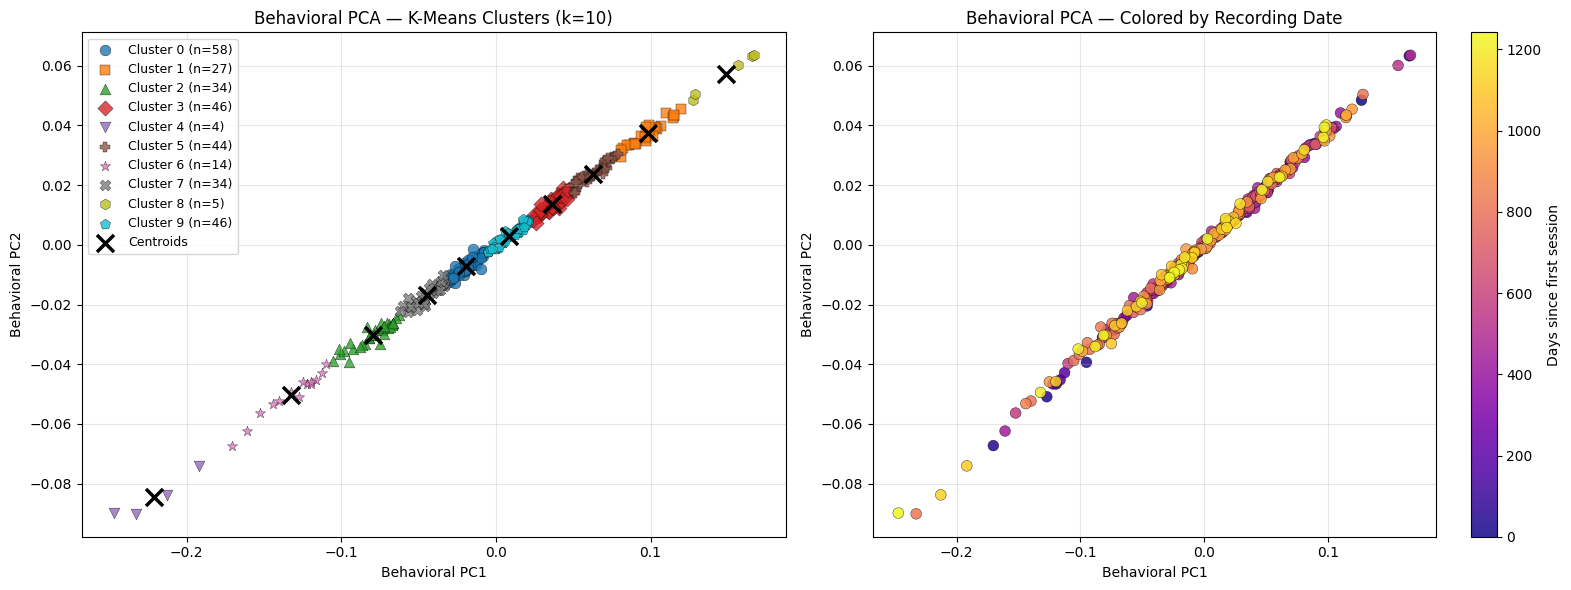

Saved: behavioral_pca_clusters.png


In [10]:
## Plot: 2D Behavioral PCA — one point per day, colored by cluster
import matplotlib.cm as cm

# Dynamically generate colors and markers based on K
ALL_MARKERS = ['o', 's', '^', 'D', 'v', 'P', '*', 'X', 'h', 'p']
cmap_clusters = cm.get_cmap('tab10' if K <= 10 else 'tab20')
COLORS  = [cmap_clusters(k / K) for k in range(K)]
MARKERS = [ALL_MARKERS[k % len(ALL_MARKERS)] for k in range(K)]

days_since_start = np.array([(d - day_dates.min()).days for d in day_dates])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left: colored by k-means cluster ---
ax = axes[0]
for k in range(K):
    mask = labels == k
    ax.scatter(day_points[mask, 0], day_points[mask, 1],
               c=[COLORS[k]], marker=MARKERS[k], s=60, alpha=0.8,
               label=f'Cluster {k} (n={mask.sum()})', edgecolors='k', linewidths=0.3)
ax.scatter(centers[:, 0], centers[:, 1], c='black', marker='x', s=150, linewidths=2.5,
           zorder=5, label='Centroids')
ax.set_xlabel('Behavioral PC1')
ax.set_ylabel('Behavioral PC2')
ax.set_title(f'Behavioral PCA — K-Means Clusters (k={K})')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# --- Right: colored by time (days since first session) ---
ax = axes[1]
sc = ax.scatter(day_points[:, 0], day_points[:, 1],
                c=days_since_start, cmap='plasma', s=60, alpha=0.85,
                edgecolors='k', linewidths=0.3)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Days since first session')
ax.set_xlabel('Behavioral PC1')
ax.set_ylabel('Behavioral PC2')
ax.set_title('Behavioral PCA — Colored by Recording Date')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('behavioral_pca_clusters.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: behavioral_pca_clusters.png')

In [11]:
## Summary table: cluster assignments with dates
days_since_start = np.array([(d - day_dates.min()).days for d in day_dates])

summary_df = pd.DataFrame({
    'file':              day_files,
    'date':              day_dates,
    'days_since_start':  days_since_start,
    'pc1':               day_points[:, 0],
    'pc2':               day_points[:, 1],
    'cluster':           labels,
})
summary_df = summary_df.sort_values('date').reset_index(drop=True)
print(summary_df.groupby('cluster')[['pc1', 'pc2', 'days_since_start']].describe().round(3))
summary_df.head(10)

          pc1                                                    pc2         \
        count   mean    std    min    25%    50%    75%    max count   mean   
cluster                                                                       
0        58.0 -0.019  0.007 -0.031 -0.024 -0.019 -0.015 -0.008  58.0 -0.007   
1        27.0  0.098  0.011  0.081  0.090  0.098  0.104  0.120  27.0  0.037   
2        34.0 -0.079  0.012 -0.105 -0.086 -0.077 -0.070 -0.063  34.0 -0.030   
3        46.0  0.036  0.008  0.024  0.029  0.036  0.043  0.049  46.0  0.014   
4         4.0 -0.221  0.024 -0.247 -0.236 -0.223 -0.208 -0.192   4.0 -0.084   
5        44.0  0.062  0.009  0.051  0.055  0.062  0.070  0.079  44.0  0.024   
6        14.0 -0.132  0.019 -0.170 -0.143 -0.126 -0.120 -0.110  14.0 -0.050   
7        34.0 -0.044  0.008 -0.062 -0.050 -0.044 -0.036 -0.033  34.0 -0.017   
8         5.0  0.149  0.020  0.127  0.128  0.157  0.166  0.167   5.0  0.057   
9        46.0  0.008  0.008 -0.005  0.002  0.009  0.

,file,date,days_since_start,pc1,pc2,cluster
0,sub-Monkey-N_ses-20200127_ecephys.nwb,2020-01-27,0,0.054515,0.021122,5
1,sub-Monkey-N_ses-20200130_ecephys.nwb,2020-01-30,3,0.127237,0.048464,8
2,sub-Monkey-N_ses-20200204_ecephys.nwb,2020-02-04,8,0.089271,0.033965,1
3,sub-Monkey-N_ses-20200205_ecephys.nwb,2020-02-05,9,0.069928,0.026865,5
4,sub-Monkey-N_ses-20200206_ecephys.nwb,2020-02-06,10,0.075999,0.029137,5
5,sub-Monkey-N_ses-20200211_ecephys.nwb,2020-02-11,15,0.165905,0.063331,8
6,sub-Monkey-N_ses-20200222_ecephys.nwb,2020-02-22,26,0.050525,0.020130,5
7,sub-Monkey-N_ses-20200224_ecephys.nwb,2020-02-24,28,0.056832,0.021762,5
8,sub-Monkey-N_ses-20200225_ecephys.nwb,2020-02-25,29,0.032996,0.013135,3
9,sub-Monkey-N_ses-20200228_ecephys.nwb,2020-02-28,32,-0.082211,-0.031052,2


## Long-Term Neural Activity: Mean SBP Across Sessions (Largest Cluster)

For each session in the most numerous cluster, extract all trials, compute the mean SpikingBandPower (averaged over time bins and channels), then plot it over time to look for long-term drift.

In [12]:

# Identify the most numerous cluster
largest_cluster = int(np.bincount(labels).argmax())
cluster_mask = labels == largest_cluster
cluster_files = np.array(day_files)[cluster_mask]
cluster_dates = day_dates[cluster_mask]

# Sort by date
order = np.argsort(cluster_dates)
cluster_files = cluster_files[order]
cluster_dates = cluster_dates[order]

print(f'Largest cluster: {largest_cluster}  ({cluster_mask.sum()} sessions)')

def time_to_bin(t, bin_size=0.004):
    return int(round(t / bin_size))

session_mean_sbp = []
session_std_sbp  = []

for fname in cluster_files:
    path = os.path.join(DATA_DIR, fname)
    with NWBHDF5IO(path, 'r') as io:
        nwb = io.read()
        sbp_raw = nwb.analysis['SpikingBandPower'].data[:] / 0.25
        trials  = nwb.trials.to_dataframe()

    total_bins = sbp_raw.shape[0]
    trial_means = []
    trial_stds  = []
    for _, trial in trials.iterrows():
        s = min(time_to_bin(trial['start_time']), total_bins)
        e = min(time_to_bin(trial['stop_time']),  total_bins)
        if e > s:
            chunk = sbp_raw[s:e]
            trial_means.append(chunk.mean())
            trial_stds.append(chunk.std())

    session_mean_sbp.append(np.mean(trial_means) if trial_means else np.nan)
    session_std_sbp.append( np.mean(trial_stds)  if trial_stds  else np.nan)

session_mean_sbp = np.array(session_mean_sbp)
session_std_sbp  = np.array(session_std_sbp)
print(f'Computed stats for {len(session_mean_sbp)} sessions')
print(f'Mean SBP range: [{np.nanmin(session_mean_sbp):.3f}, {np.nanmax(session_mean_sbp):.3f}]')
print(f'Std  SBP range: [{np.nanmin(session_std_sbp):.3f},  {np.nanmax(session_std_sbp):.3f}]')


Largest cluster: 0  (58 sessions)
Computed stats for 58 sessions
Mean SBP range: [7.826, 20.187]
Std  SBP range: [2.909,  29.751]


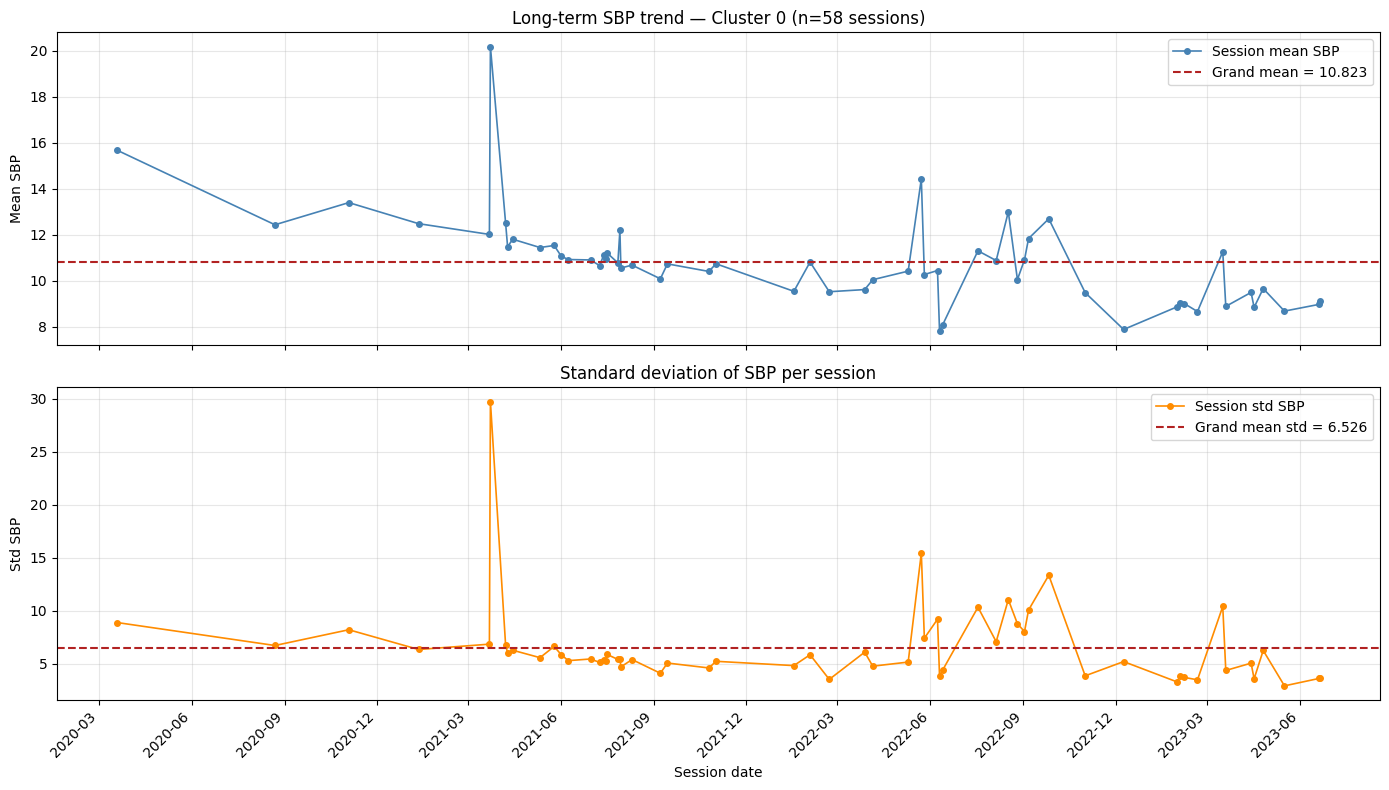

Saved: sbp_longterm_cluster.png


In [13]:

import matplotlib.dates as mdates

grand_mean = np.nanmean(session_mean_sbp)
grand_std  = np.nanmean(session_std_sbp)
cluster_dates_dt = [pd.Timestamp(d) for d in cluster_dates]

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(cluster_dates_dt, session_mean_sbp, marker='o', markersize=4,
             linewidth=1.2, color='steelblue', label='Session mean SBP')
axes[0].axhline(grand_mean, color='firebrick', linewidth=1.5, linestyle='--',
                label=f'Grand mean = {grand_mean:.3f}')
axes[0].set_ylabel('Mean SBP')
axes[0].set_title(f'Long-term SBP trend — Cluster {largest_cluster} (n={len(session_mean_sbp)} sessions)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(cluster_dates_dt, session_std_sbp, marker='o', markersize=4,
             linewidth=1.2, color='darkorange', label='Session std SBP')
axes[1].axhline(grand_std, color='firebrick', linewidth=1.5, linestyle='--',
                label=f'Grand mean std = {grand_std:.3f}')
axes[1].set_ylabel('Std SBP')
axes[1].set_title('Standard deviation of SBP per session')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].set_xlabel('Session date')

plt.tight_layout()
plt.savefig('sbp_longterm_cluster.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: sbp_longterm_cluster.png')
